In [18]:
import pygmt
import obspy
from pyfwat.utils.pario import readfkpar
import pandas as pd

In [28]:
def read_cmtsolution(filename):
    with open(filename) as f:
        lines = f.readlines()
    cmtsolution = {
        "latitude": float(lines[4].strip().split()[1]),
        "longitude": float(lines[5].strip().split()[1]),
        "depth": float(lines[6].strip().split()[1]),
        "mrr": float(lines[7].strip().split()[1]),
        "mtt": float(lines[8].strip().split()[1]),
        "mff": float(lines[9].strip().split()[1]),
        "mrt": float(lines[10].strip().split()[1]),
        "mrf": float(lines[11].strip().split()[1]),
        "mtf": float(lines[12].strip().split()[1]),
        "exponent": 1.
    }
    return cmtsolution


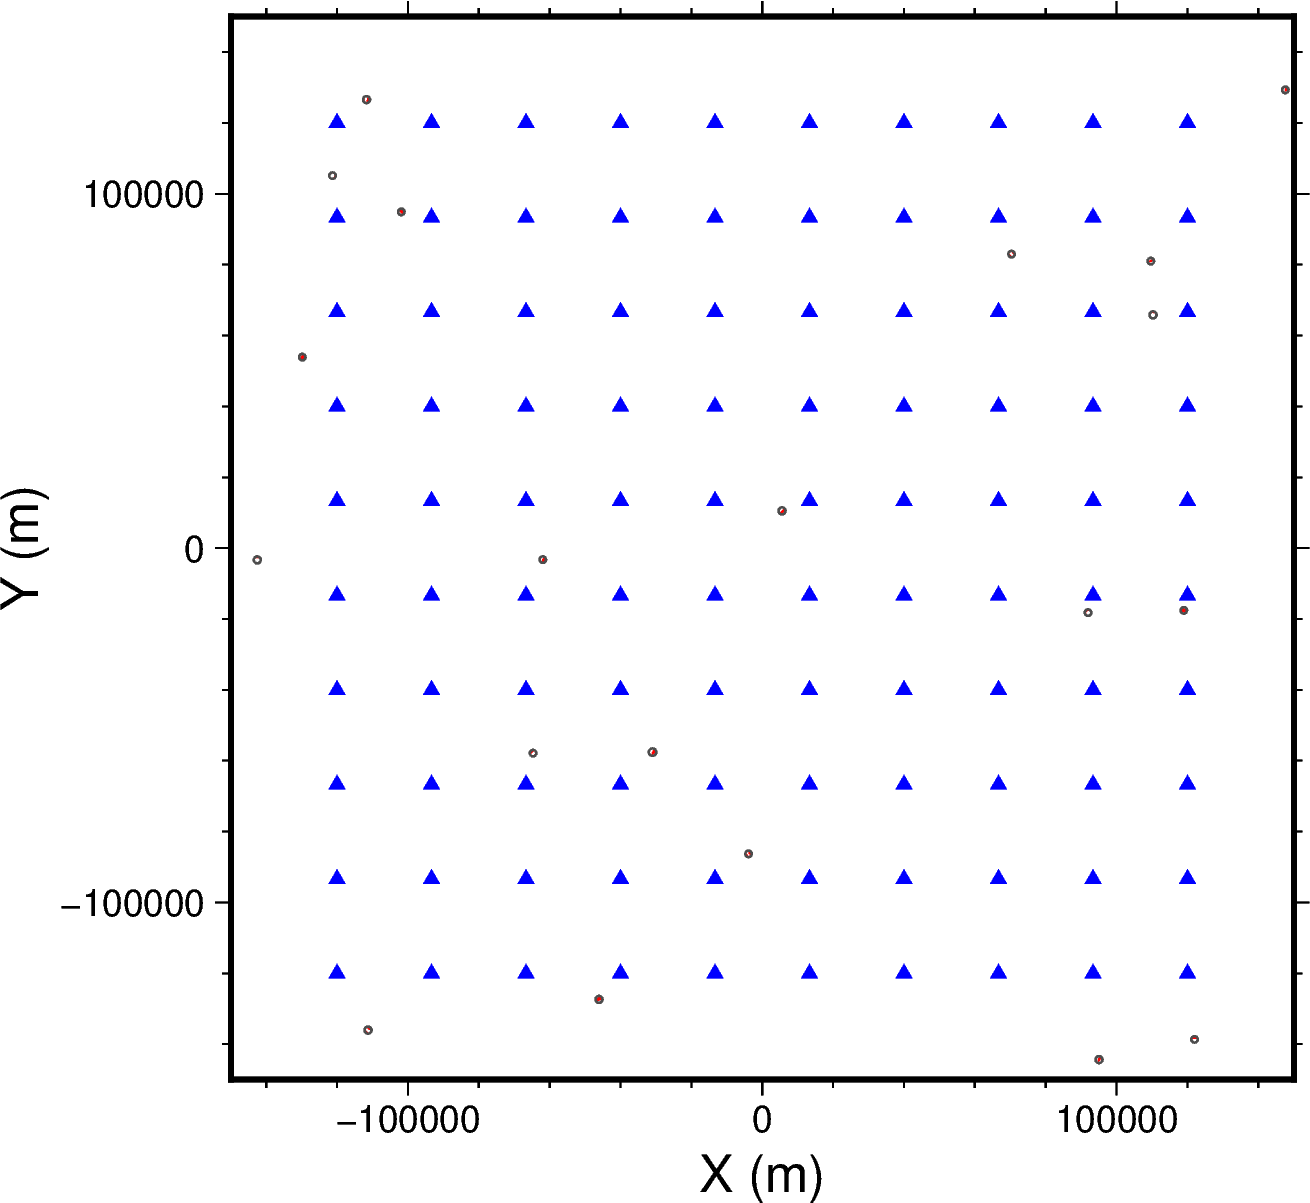

In [ ]:
xmin, xmax = -150000, 150000
ymin, ymax = -150000, 150000
zmin, zmax = -50000, 0

sta = pd.read_csv('./src_rec/STATIONS_EV01', sep=r'\s+', header=None)
evt = pd.read_csv('./src_rec/sources_leq.dat', sep=r'\s+', header=None)

fig = pygmt.Figure()
fig.basemap(
    region=[xmin, xmax, ymin, ymax],
    projection="x0.00003c",
    frame=["WSne", "xaf+lX (m)", "yaf+lY (m)"],
)
fig.plot(x=sta[3], y=sta[2], style="t0.16c", fill="blue", label="Stations")
for i, ev in evt.iterrows():
    cmtsol = read_cmtsolution(f'./src_rec/CMTSOLUTION_{ev[0]}')
    fig.meca(
        spec=cmtsol,
        longitude=cmtsol["longitude"],
        latitude=cmtsol["latitude"],
        depth=cmtsol["depth"],
        compressionfill="red",
        pen="0.5p,gray30,solid",
        scale=0.1,
    )
fig.show()  